In [33]:
files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
from google.colab import files

files.download("house_price_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import joblib

if best_model_name == "Linear Regression":
    joblib.dump(linear_model, "house_price_model.pkl")
else:
    joblib.dump(tree_model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [30]:
df.to_csv("house_price_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [29]:
print("======================================")
print(" HOUSE PRICE PREDICTION - FINAL RESULT")
print("======================================")

print("\nLinear Regression:")
print("MAE :", round(mae_linear, 2))
print("RMSE:", round(rmse_linear, 2))
print("R²  :", round(r2_linear, 4))

print("\nDecision Tree:")
print("MAE :", round(mae_tree, 2))
print("RMSE:", round(rmse_tree, 2))
print("R²  :", round(r2_tree, 4))

print("\nBest Model:", best_model_name)

 HOUSE PRICE PREDICTION - FINAL RESULT

Linear Regression:
MAE : 23938.04
RMSE: 83001.57
R²  : 0.1018

Decision Tree:
MAE : 25931.36
RMSE: 40771.24
R²  : 0.7833

Best Model: Decision Tree


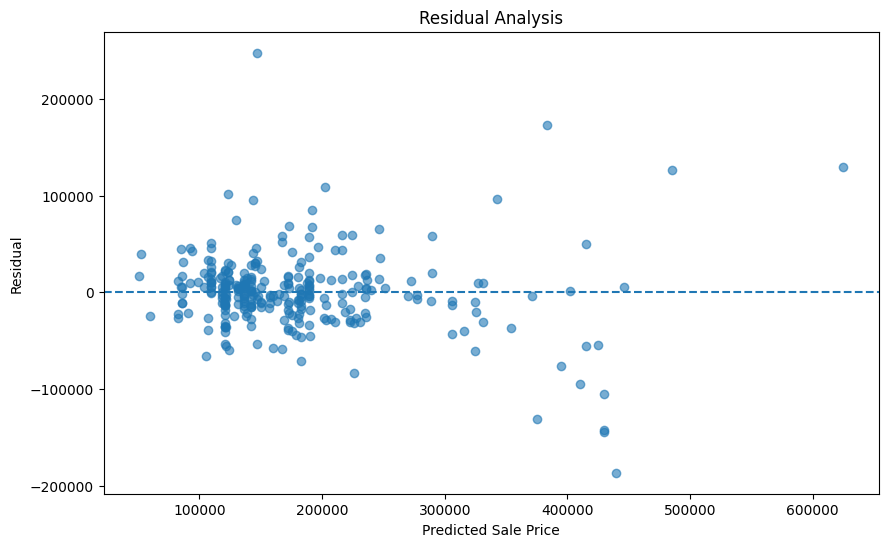

In [28]:
residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))

plt.scatter(best_predictions, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

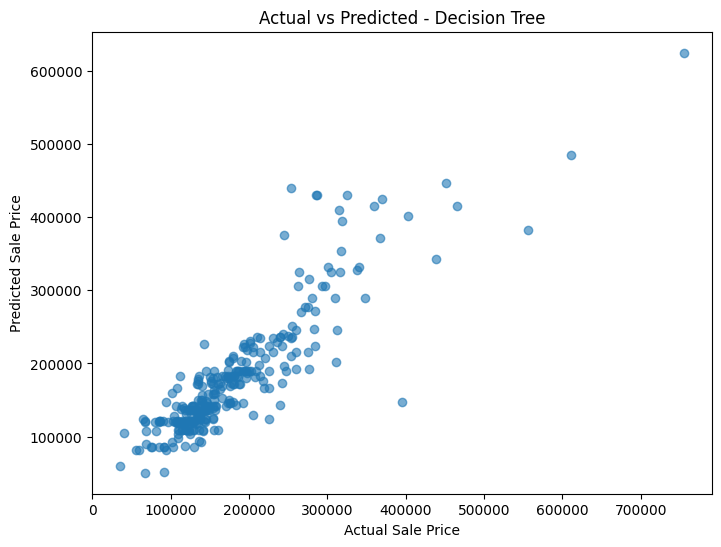

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, best_predictions, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title(f"Actual vs Predicted - {best_model_name}")

plt.show()

In [26]:
if r2_linear >= r2_tree:
    best_model_name = "Linear Regression"
    best_predictions = y_pred_linear
else:
    best_model_name = "Decision Tree"
    best_predictions = y_pred_tree

print("Best model based on R²:", best_model_name)

Best model based on R²: Decision Tree


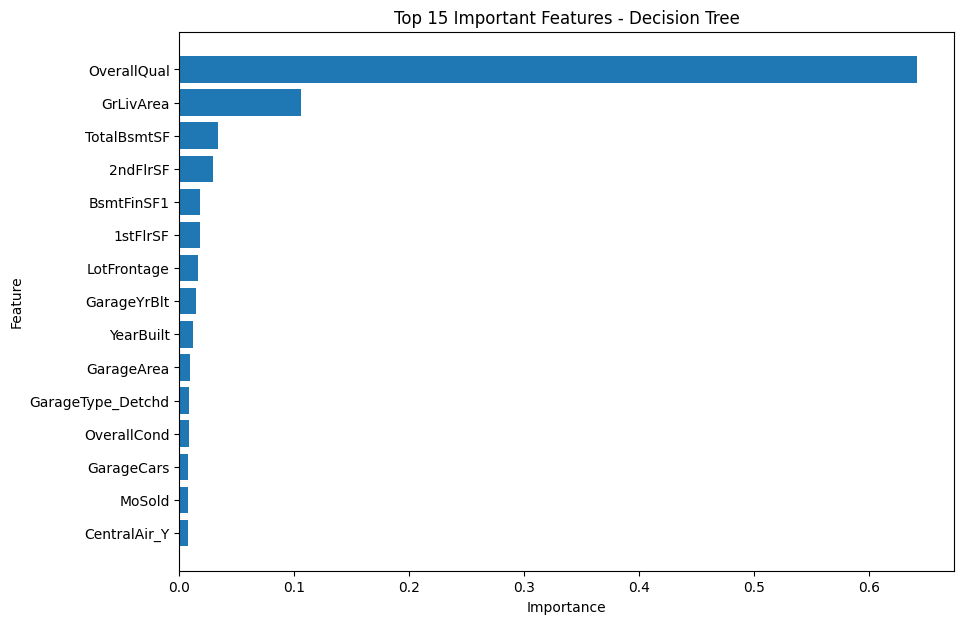

In [25]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features - Decision Tree")

plt.show()

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,OverallQual,0.641901
16,GrLivArea,0.105759
12,TotalBsmtSF,0.033821
14,2ndFlrSF,0.029360
9,BsmtFinSF1,0.018238
13,1stFlrSF,0.018094
2,LotFrontage,0.016143
25,GarageYrBlt,0.014300
6,YearBuilt,0.011645
27,GarageArea,0.009221


In [23]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree"
    ],
    "MAE": [
        mae_linear,
        mae_tree
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree
    ],
    "R2": [
        r2_linear,
        r2_tree
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,23938.038532,83001.569890,0.101830
1,Decision Tree,25931.363390,40771.237797,0.783283


In [22]:
from sklearn.tree import DecisionTreeRegressor

# Create model
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

# Train
tree_model.fit(X_train, y_train)

# Predict
y_pred_tree = tree_model.predict(X_test)

# Evaluate
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("---------------------")
print("MAE :", mae_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree Results
---------------------
MAE : 25931.363389852948
RMSE: 40771.237797214875
R²  : 0.7832825115104665


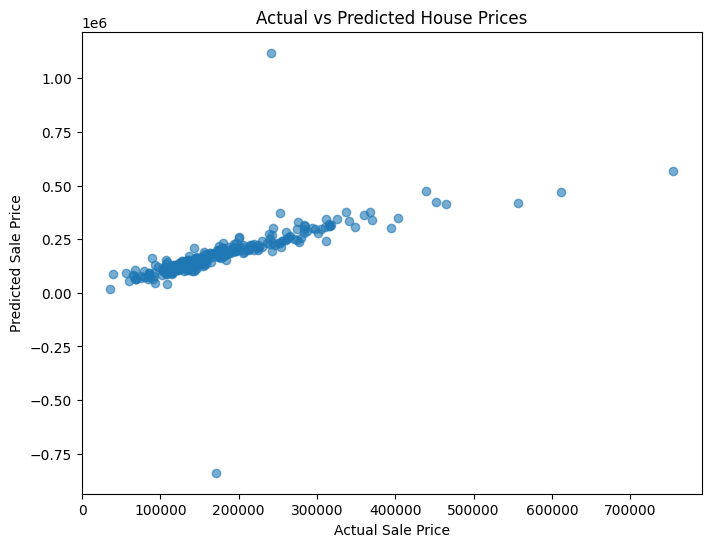

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Predictions
y_pred_linear = linear_model.predict(X_test)

# Evaluation
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 23938.038532000388
RMSE: 83001.5698903217
R²  : 0.10182951569873344


In [19]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 260)
Testing data: (292, 260)


In [17]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape[1])
print("Target shape:", y.shape)

Features after encoding: 260
Target shape: (1460,)


In [16]:
# Separate target variable

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape[1])
print("Target shape:", y.shape)

Features after encoding: 260
Target shape: (1460,)


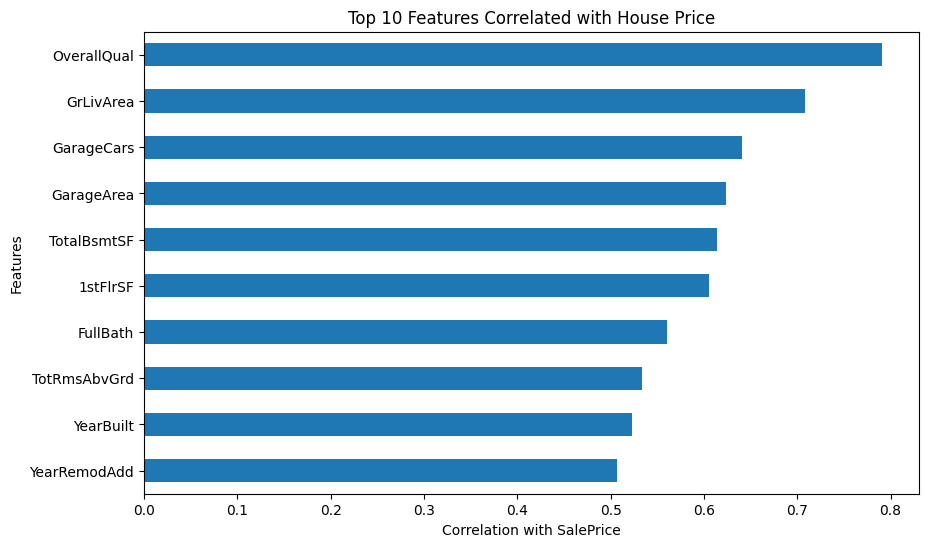

In [15]:
# Top 10 features correlated with SalePrice

top_corr = correlation.head(11).drop("SalePrice")

plt.figure(figsize=(10, 6))

top_corr.sort_values().plot(kind="barh")

plt.title("Top 10 Features Correlated with House Price")
plt.xlabel("Correlation with SalePrice")
plt.ylabel("Features")

plt.show()

In [14]:
# Find features most correlated with SalePrice

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()["SalePrice"].sort_values(ascending=False)

print("Top features correlated with SalePrice:")
print(correlation.head(10))

Top features correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


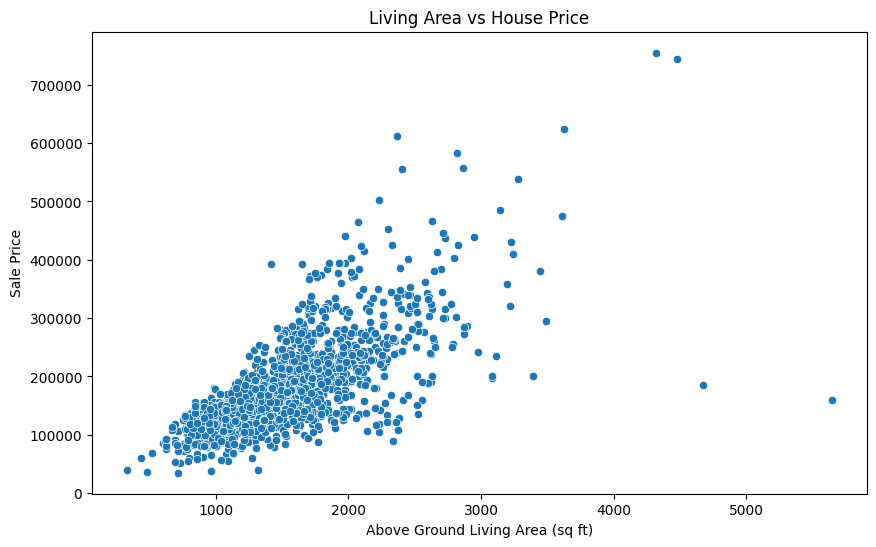

In [13]:
# Living Area vs House Price

plt.figure(figsize=(10, 6))

sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])

plt.title("Living Area vs House Price")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price")

plt.show()

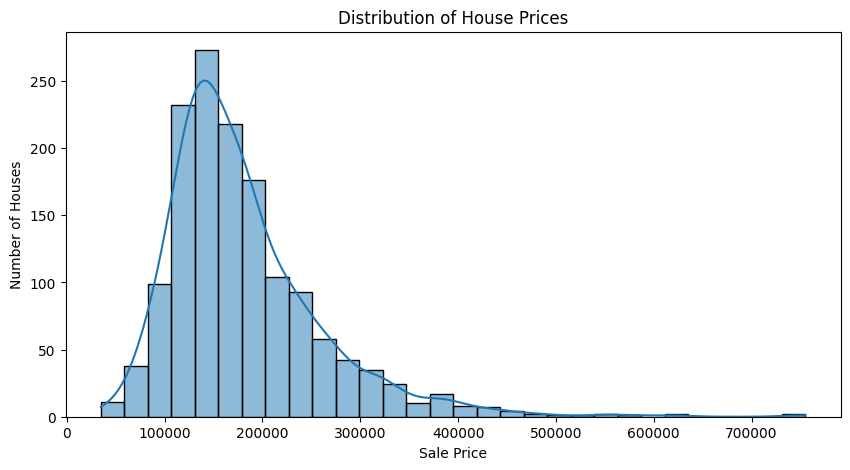

In [12]:
# Distribution of House Prices

plt.figure(figsize=(10, 5))

sns.histplot(df["SalePrice"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")

plt.show()

In [11]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
# Handle missing values

# Missing categorical values = feature not present
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence",
    "FireplaceQu", "GarageType", "GarageFinish",
    "GarageQual", "GarageCond", "BsmtQual",
    "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "MasVnrType"
]

for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")

# Missing numerical values = no related feature
zero_cols = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath",
    "MasVnrArea"
]

for col in zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# LotFrontage: fill with neighborhood median
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# Remaining categorical columns
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remaining numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("Missing values handled successfully!")

Missing values handled successfully!


In [8]:
# Check missing values

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing_Count"] > 0] \
    .sort_values("Missing_Count", ascending=False)

missing

,Missing_Count,Missing_Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [7]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1460
Columns: 81


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Show the number of missing values as percentages

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

print(missing_percent)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [ ]:
# Count missing values in each column

missing = df.isnull().sum()

# Show only columns that have missing values
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [ ]:
# Check the data types of all columns

df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [ ]:
# Basic statistics of house prices

df["SalePrice"].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [ ]:
# Check for duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# Check missing values in every column

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Display the first 5 rows

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Load the house price dataset

df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully!
Number of rows: 1460
Number of columns: 81


In [ ]:
# Importing the basic libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!
